# Divvy Bike Share - Rider Behaviour Analysis

**Author:** Anjana  
**Date:** April 2026

# Project Description

The dataset used is a public historical trip data from Divvy, a Chicago based rideshare company, for the years 2019 and 2020 for Q1. This project includes data pre-processing, feature engineering and explorative data analysis. The goal is to understand the pattern seen in both datasets for years 2019 Q1 and 2020 Q1.

#### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Step 1: Data Loading and Pre-processing

In [2]:
# Load the files
df2019 = pd.read_csv('Divvy_Trips_2019_Q1.csv')
df2020 = pd.read_csv('Divvy_Trips_2020_Q1.csv')

In [3]:
df2019.head() # View the first 5 rows

,trip_id,start_time,end_time,bikeid,tripduration,from_station_id,from_station_name,to_station_id,to_station_name,usertype,gender,birthyear,Unnamed: 12,Unnamed: 13,Unnamed: 14,birth_year_sum,Unnamed: 16,Unnamed: 17
0,21742443,1/1/19 0:04,1/1/19 0:11,2167,390,199,Wabash Ave & Grand Ave,84,Milwaukee Ave & Grand Ave,Subscriber,Male,1989.0,NaN,NaN,Max:,2003,NaN,NaN
1,21742444,1/1/19 0:08,1/1/19 0:15,4386,441,44,State St & Randolph St,624,Dearborn St & Van Buren St (*),Subscriber,Female,1990.0,NaN,NaN,Min:,1900,NaN,69.0
2,21742445,1/1/19 0:13,1/1/19 0:27,1524,829,15,Racine Ave & 18th St,644,Western Ave & Fillmore St (*),Subscriber,Female,1994.0,NaN,NaN,Median:,1985,NaN,NaN
3,21742446,1/1/19 0:13,1/1/19 0:43,252,"1,783.00",123,California Ave & Milwaukee Ave,176,Clark St & Elm St,Subscriber,Male,1993.0,NaN,NaN,Mode:,1989,NaN,NaN
4,21742447,1/1/19 0:14,1/1/19 0:20,1170,364,173,Mies van der Rohe Way & Chicago Ave,35,Streeter Dr & Grand Ave,Subscriber,Male,1994.0,NaN,NaN,Average:,1981.674297,NaN,NaN


In [4]:
df2020.head() # View the first 5 rows

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,EACB19130B0CDA4A,docked_bike,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,239,Clark St & Leland Ave,326.0,41.9665,-87.6884,41.9671,-87.6674,member
1,8FED874C809DC021,docked_bike,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,234,Southport Ave & Irving Park Rd,318.0,41.9616,-87.6660,41.9542,-87.6644,member
2,789F3C21E472CA96,docked_bike,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,296,Wilton Ave & Belmont Ave,117.0,41.9401,-87.6455,41.9402,-87.6530,member
3,C9A388DAC6ABF313,docked_bike,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,51,Fairbanks Ct & Grand Ave,24.0,41.8846,-87.6319,41.8918,-87.6206,member
4,943BC3CBECCFD662,docked_bike,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,66,Wells St & Hubbard St,212.0,41.8856,-87.6418,41.8899,-87.6343,member


In [5]:
print(f"Number of rows and columns in the 2019 dataset: {df2019.shape[0]}, {df2019.shape[1]}")
print(f"Number of rows and columns in the 2020 dataset: {df2020.shape[0]}, {df2020.shape[1]}")

Number of rows and columns in the 2019 dataset: 365069, 18
Number of rows and columns in the 2020 dataset: 426887, 13


In [6]:
df2019.info()

<class 'pandas.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   trip_id            365069 non-null  int64  
 1   start_time         365069 non-null  str    
 2   end_time           365069 non-null  str    
 3   bikeid             365069 non-null  int64  
 4   tripduration       365069 non-null  str    
 5   from_station_id    365069 non-null  int64  
 6   from_station_name  365069 non-null  str    
 7   to_station_id      365069 non-null  int64  
 8   to_station_name    365069 non-null  str    
 9   usertype           365069 non-null  str    
 10  gender             345358 non-null  str    
 11  birthyear          347046 non-null  float64
 12  Unnamed: 12        0 non-null       float64
 13  Unnamed: 13        0 non-null       float64
 14  Unnamed: 14        10 non-null      str    
 15  birth_year_sum     11 non-null      str    
 16  Unnamed: 16  

In [7]:
df2020.info()

<class 'pandas.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             426887 non-null  str    
 1   rideable_type       426887 non-null  str    
 2   started_at          426887 non-null  str    
 3   ended_at            426887 non-null  str    
 4   start_station_name  426887 non-null  str    
 5   start_station_id    426887 non-null  int64  
 6   end_station_name    426886 non-null  str    
 7   end_station_id      426886 non-null  float64
 8   start_lat           426887 non-null  float64
 9   start_lng           426887 non-null  float64
 10  end_lat             426886 non-null  float64
 11  end_lng             426886 non-null  float64
 12  member_casual       426887 non-null  str    
dtypes: float64(5), int64(1), str(7)
memory usage: 42.3 MB


In [8]:
df2019.isnull().sum()

trip_id                   0
start_time                0
end_time                  0
bikeid                    0
tripduration              0
from_station_id           0
from_station_name         0
to_station_id             0
to_station_name           0
usertype                  0
gender                19711
birthyear             18023
Unnamed: 12          365069
Unnamed: 13          365069
Unnamed: 14          365059
birth_year_sum       365058
Unnamed: 16          365069
Unnamed: 17          365068
dtype: int64

In [9]:
df2020.isnull().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      1
end_station_id        1
start_lat             0
start_lng             0
end_lat               1
end_lng               1
member_casual         0
dtype: int64

### Step 1.1: Data Cleaning of 2019 data

In [10]:
# Drop columns with majority missing values
df2019 = df2019.drop(['Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'birth_year_sum', 'Unnamed: 16', 'Unnamed: 17'], axis=1)

In [11]:
# Rename columns
df2019 = df2019.rename(columns={
    'trip_id': 'ride_id',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'tripduration': 'ride_duration_sec',
    'from_station_id': 'start_station_id',
    'from_station_name': 'start_station_name',
    'to_station_id': 'end_station_id',
    'to_station_name': 'end_station_name',
    'usertype': 'member_casual'
})

In [12]:
# Map rider labels to match with the 2020 data
df2019['member_casual'] = df2019['member_casual'].map({'Subscriber': 'member', 'Customer': 'casual'})

In [13]:
# Save for later analysis
df2019_demographics = df2019[['member_casual', 'gender', 'birthyear']].copy()

# Drop the columns gender and birthyear which has majority null values. bikeid is not a relevant column. Hence drop.
df2019 = df2019.drop(['bikeid', 'gender', 'birthyear'], axis=1)

In [14]:
# Recheck for nulls
df2019.isnull().sum()

ride_id               0
started_at            0
ended_at              0
ride_duration_sec     0
start_station_id      0
start_station_name    0
end_station_id        0
end_station_name      0
member_casual         0
dtype: int64

In [15]:
# Convert the ride_duration_sec column to numeric
df2019['ride_duration_sec'] = pd.to_numeric(df2019['ride_duration_sec'].str.replace(',', ''), errors='coerce')

In [16]:
# Convert duration from seconds to minutes
df2019['ride_duration_min'] = df2019['ride_duration_sec'] / 60
df2019 = df2019.drop('ride_duration_sec', axis=1)

In [17]:
# Convert date columns to the correct date format
df2019['started_at'] = pd.to_datetime(df2019['started_at'])
df2019['ended_at'] = pd.to_datetime(df2019['ended_at'])

In [18]:
# Add year column
df2019['year'] = 2019

In [19]:
# Check if there are any duplicates in ride_id
print(df2019['ride_id'].duplicated().sum())

0


In [20]:
# No duplicates found. Hence drop the ride_id column
df2019 = df2019.drop('ride_id', axis=1)

In [21]:
# Drop the start and end station ids as station names are already present
df2019 = df2019.drop(['start_station_id', 'end_station_id'], axis=1)

In [22]:
df2019.head()

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year
0,2019-01-01 00:04:00,2019-01-01 00:11:00,Wabash Ave & Grand Ave,Milwaukee Ave & Grand Ave,member,6.500000,2019
1,2019-01-01 00:08:00,2019-01-01 00:15:00,State St & Randolph St,Dearborn St & Van Buren St (*),member,7.350000,2019
2,2019-01-01 00:13:00,2019-01-01 00:27:00,Racine Ave & 18th St,Western Ave & Fillmore St (*),member,13.816667,2019
3,2019-01-01 00:13:00,2019-01-01 00:43:00,California Ave & Milwaukee Ave,Clark St & Elm St,member,29.716667,2019
4,2019-01-01 00:14:00,2019-01-01 00:20:00,Mies van der Rohe Way & Chicago Ave,Streeter Dr & Grand Ave,member,6.066667,2019


In [23]:
df2019['member_casual'].value_counts()

member_casual
member    341906
casual     23163
Name: count, dtype: int64

In [24]:
df2019['ride_duration_min'].describe()

count    365069.000000
mean         16.939034
std         465.225151
min           1.016667
25%           5.433333
50%           8.733333
75%          14.433333
max      177140.000000
Name: ride_duration_min, dtype: float64

- No records found with ride duration les than 1 minute
- Outliers found with max value showing 177140 minutes

In [25]:
# Outlier treatment using IQR rule
Q1 = df2019['ride_duration_min'].quantile(0.25)
Q3 = df2019['ride_duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"2019 - Lower: {lower:.2f}, Upper: {upper:.2f}")

2019 - Lower: -8.07, Upper: 27.93


In [26]:
# Cap outliers at lower and upper whisker values
df2019['ride_duration_min'] = df2019['ride_duration_min'].clip(lower=lower, upper=upper)

In [27]:
df2019['ride_duration_min'].describe()

count    365069.000000
mean         10.974998
std           7.295697
min           1.016667
25%           5.433333
50%           8.733333
75%          14.433333
max          27.933333
Name: ride_duration_min, dtype: float64

In [28]:
df2019.shape

(365069, 7)

### Step 1.2: Data Cleaning of 2020 data

In [29]:
# Drop columns that are not useful
df2020 = df2020.drop(['rideable_type', 'start_lat', 'start_lng', 'end_lat', 'end_lng'], axis=1)

In [30]:
# Drop records with end station name null
df2020.dropna(subset=['end_station_name'], inplace=True)

In [31]:
df2020.isnull().sum()

ride_id               0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
member_casual         0
dtype: int64

In [32]:
# Convert columns to date format
df2020['started_at'] = pd.to_datetime(df2020['started_at'])
df2020['ended_at'] = pd.to_datetime(df2020['ended_at'])

In [33]:
# Calculate ride duration
df2020['ride_duration_min'] = (df2020['ended_at'] - df2020['started_at']).dt.total_seconds() / 60

In [34]:
# Add year column
df2020['year'] = 2020

In [35]:
df2020['member_casual'].value_counts()

member_casual
member    378407
casual     48479
Name: count, dtype: int64

In [36]:
# Check if there are any duplicates in ride_id
print(df2020['ride_id'].duplicated().sum())

0


In [37]:
# No duplicates found. Hence drop the ride_id column
df2020 = df2020.drop('ride_id', axis=1)

In [38]:
# Drop the start and end station ids as station names are already present
df2020 = df2020.drop(['start_station_id', 'end_station_id'], axis=1)

In [39]:
df2020.head()

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year
0,2020-01-21 20:06:59,2020-01-21 20:14:30,Western Ave & Leland Ave,Clark St & Leland Ave,member,7.516667,2020
1,2020-01-30 14:22:39,2020-01-30 14:26:22,Clark St & Montrose Ave,Southport Ave & Irving Park Rd,member,3.716667,2020
2,2020-01-09 19:29:26,2020-01-09 19:32:17,Broadway & Belmont Ave,Wilton Ave & Belmont Ave,member,2.850000,2020
3,2020-01-06 16:17:07,2020-01-06 16:25:56,Clark St & Randolph St,Fairbanks Ct & Grand Ave,member,8.816667,2020
4,2020-01-30 08:37:16,2020-01-30 08:42:48,Clinton St & Lake St,Wells St & Hubbard St,member,5.533333,2020


In [40]:
df2020['ride_duration_min'].describe()

count    426886.000000
mean         22.115157
std         619.042270
min          -9.200000
25%           5.483333
50%           9.166667
75%          15.816667
max      156450.400000
Name: ride_duration_min, dtype: float64

**Inference**

- ride_duration_min contains negative values

In [41]:
# Check for records with ride duration less than 1 minute
df2020[df2020['ride_duration_min'] < 1].shape[0]

7670

In [42]:
# Keep records with ride duration greater than or equal to 1 minute
df2020 = df2020[df2020['ride_duration_min'] >= 1]

In [43]:
df2020['ride_duration_min'].describe()

count    419216.000000
mean         22.516109
std         624.672469
min           1.000000
25%           5.650000
50%           9.316667
75%          16.016667
max      156450.400000
Name: ride_duration_min, dtype: float64

In [44]:
# Outlier treatment using IQR rule

Q1 = df2020['ride_duration_min'].quantile(0.25)
Q3 = df2020['ride_duration_min'].quantile(0.75)
IQR = Q3 - Q1


lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"2020 - Lower: {lower:.2f}, Upper: {upper:.2f}")

2020 - Lower: -9.90, Upper: 31.57


In [45]:
# Cap outliers at lower and upper whisker values
df2020['ride_duration_min'] = df2020['ride_duration_min'].clip(lower=lower, upper=upper)

In [46]:
df2020['ride_duration_min'].describe()

count    419216.000000
mean         12.041138
std           8.407711
min           1.000000
25%           5.650000
50%           9.316667
75%          16.016667
max          31.566667
Name: ride_duration_min, dtype: float64

In [47]:
df2020.shape

(419216, 7)

### Step 1.3: Data Cleaning of the demographics data

In [48]:
df2019_demographics.isnull().sum()

member_casual        0
gender           19711
birthyear        18023
dtype: int64

In [49]:
# Drop records if gender, birthyear are null because this dataset is specifically used to analyse gender and age of the riders
df2019_demographics.dropna(subset=['gender'], inplace=True)
df2019_demographics.dropna(subset=['birthyear'], inplace=True)

In [50]:
df2019_demographics.isnull().sum()

member_casual    0
gender           0
birthyear        0
dtype: int64

In [51]:
df2019_demographics['birthyear'] = df2019_demographics['birthyear'].astype('Int64')

In [52]:
df2019_demographics.head()

,member_casual,gender,birthyear
0,member,Male,1989
1,member,Female,1990
2,member,Female,1994
3,member,Male,1993
4,member,Male,1994


### Step 1.4: Merge 2019 & 2020 data

In [53]:
df2019.columns.tolist()

['started_at',
 'ended_at',
 'start_station_name',
 'end_station_name',
 'member_casual',
 'ride_duration_min',
 'year']

In [54]:
df2020.columns.tolist()

['started_at',
 'ended_at',
 'start_station_name',
 'end_station_name',
 'member_casual',
 'ride_duration_min',
 'year']

In [55]:
# Merge the 2019 and 2020 data
df = pd.concat([df2019, df2020], ignore_index=True)

In [56]:
df.shape

(784285, 7)

In [57]:
df.head()

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year
0,2019-01-01 00:04:00,2019-01-01 00:11:00,Wabash Ave & Grand Ave,Milwaukee Ave & Grand Ave,member,6.500000,2019
1,2019-01-01 00:08:00,2019-01-01 00:15:00,State St & Randolph St,Dearborn St & Van Buren St (*),member,7.350000,2019
2,2019-01-01 00:13:00,2019-01-01 00:27:00,Racine Ave & 18th St,Western Ave & Fillmore St (*),member,13.816667,2019
3,2019-01-01 00:13:00,2019-01-01 00:43:00,California Ave & Milwaukee Ave,Clark St & Elm St,member,27.933333,2019
4,2019-01-01 00:14:00,2019-01-01 00:20:00,Mies van der Rohe Way & Chicago Ave,Streeter Dr & Grand Ave,member,6.066667,2019


In [58]:
df.tail()

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year
784280,2020-03-12 07:32:25,2020-03-12 07:38:44,Clinton St & Washington Blvd,State St & Kinzie St,member,6.316667,2020
784281,2020-03-07 15:25:55,2020-03-07 16:14:03,Rush St & Superior St,Sheridan Rd & Irving Park Rd,member,31.566667,2020
784282,2020-03-01 13:12:38,2020-03-01 13:38:29,Clark St & Lincoln Ave,Ashland Ave & Division St,casual,25.850000,2020
784283,2020-03-07 18:02:45,2020-03-07 18:13:18,Franklin St & Illinois St,Stetson Ave & South Water St,member,10.550000,2020
784284,2020-03-08 13:03:57,2020-03-08 13:32:27,Dearborn St & Erie St,Michigan Ave & Oak St,casual,28.500000,2020


In [59]:
df['member_casual'].value_counts()

member_casual
member    716593
casual     67692
Name: count, dtype: int64

In [60]:
df['year'].value_counts()

year
2020    419216
2019    365069
Name: count, dtype: int64

In [61]:
# Check for nulls
df.isnull().sum()

started_at            0
ended_at              0
start_station_name    0
end_station_name      0
member_casual         0
ride_duration_min     0
year                  0
dtype: int64

In [62]:
# Round ride duration to 2 decimals
df['ride_duration_min'] = df['ride_duration_min'].round(2)

In [63]:
df.head()

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year
0,2019-01-01 00:04:00,2019-01-01 00:11:00,Wabash Ave & Grand Ave,Milwaukee Ave & Grand Ave,member,6.50,2019
1,2019-01-01 00:08:00,2019-01-01 00:15:00,State St & Randolph St,Dearborn St & Van Buren St (*),member,7.35,2019
2,2019-01-01 00:13:00,2019-01-01 00:27:00,Racine Ave & 18th St,Western Ave & Fillmore St (*),member,13.82,2019
3,2019-01-01 00:13:00,2019-01-01 00:43:00,California Ave & Milwaukee Ave,Clark St & Elm St,member,27.93,2019
4,2019-01-01 00:14:00,2019-01-01 00:20:00,Mies van der Rohe Way & Chicago Ave,Streeter Dr & Grand Ave,member,6.07,2019


# Step 2: Feature Engineering

In [64]:
# Extract time features
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()
df['month'] = df['started_at'].dt.month_name()

# Weekday vs weekend flag
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

In [65]:
df.tail(10)

,started_at,ended_at,start_station_name,end_station_name,member_casual,ride_duration_min,year,hour,day_of_week,month,is_weekend
784275,2020-03-02 06:47:31,2020-03-02 06:55:04,Clinton St & Washington Blvd,State St & Kinzie St,member,7.55,2020,6,Monday,March,False
784276,2020-03-04 07:13:56,2020-03-04 07:21:10,Wacker Dr & Washington St,State St & Kinzie St,member,7.23,2020,7,Wednesday,March,False
784277,2020-03-06 15:58:30,2020-03-06 16:05:48,State St & Kinzie St,Clinton St & Washington Blvd,member,7.30,2020,15,Friday,March,False
784278,2020-03-08 17:22:42,2020-03-08 17:28:34,Green St & Randolph St,Aberdeen St & Jackson Blvd,member,5.87,2020,17,Sunday,March,True
784279,2020-03-25 17:10:10,2020-03-25 17:47:34,Lakeview Ave & Fullerton Pkwy,Lakefront Trail & Bryn Mawr Ave,member,31.57,2020,17,Wednesday,March,False
784280,2020-03-12 07:32:25,2020-03-12 07:38:44,Clinton St & Washington Blvd,State St & Kinzie St,member,6.32,2020,7,Thursday,March,False
784281,2020-03-07 15:25:55,2020-03-07 16:14:03,Rush St & Superior St,Sheridan Rd & Irving Park Rd,member,31.57,2020,15,Saturday,March,True
784282,2020-03-01 13:12:38,2020-03-01 13:38:29,Clark St & Lincoln Ave,Ashland Ave & Division St,casual,25.85,2020,13,Sunday,March,True
784283,2020-03-07 18:02:45,2020-03-07 18:13:18,Franklin St & Illinois St,Stetson Ave & South Water St,member,10.55,2020,18,Saturday,March,True
784284,2020-03-08 13:03:57,2020-03-08 13:32:27,Dearborn St & Erie St,Michigan Ave & Oak St,casual,28.50,2020,13,Sunday,March,True


In [66]:
# Adding age
df2019_demographics['age'] = 2019 - df2019_demographics['birthyear']

In [67]:
df2019_demographics['age'].describe()

count     345357.0
mean     37.312821
std      11.247796
min           16.0
25%           29.0
50%           34.0
75%           44.0
max          119.0
Name: age, dtype: Float64

# Step 3: EDA

### 3.1 Age distribution analysis of 2019 data

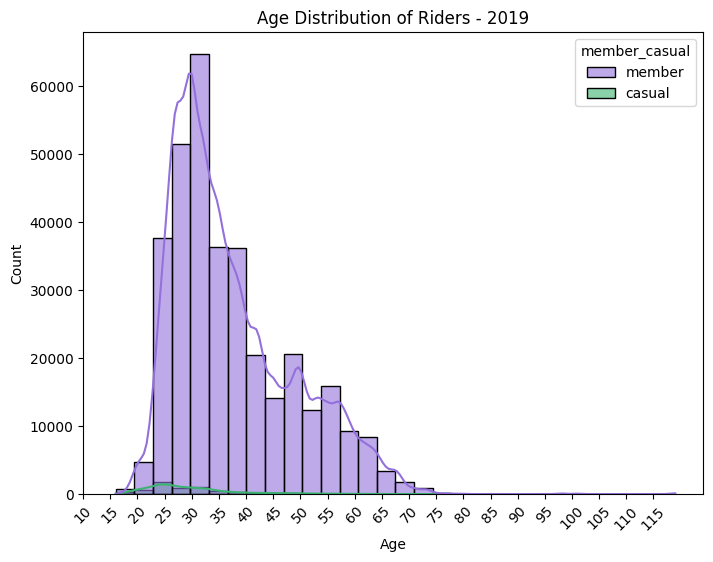

In [68]:
# Histogram of age distribution of the riders of 2019
plt.figure(figsize=(8, 6))
sns.histplot(data=df2019_demographics, x='age', hue='member_casual',
             bins=30, kde=True, alpha=0.6,
             palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'})
plt.title('Age Distribution of Riders - 2019')
plt.xlabel('Age')
plt.ylabel('Count')
plt.xticks(range(10, 120, 5), rotation=45)
plt.show()

##### Inference:

- Right skewed: Most riders are young, tail extends to the right
- Majority of the riders fall under the age 30-35 years
- Member riders are significantly above casual riders
- All the riders above 75 look like outliers

In [69]:
# Calculate Q1, Q2 and Q3 values of 'member' riders
member_subset = df2019_demographics[df2019_demographics['member_casual'] == 'member']['age']

member_q1 = int(member_subset.quantile(0.25))
member_median = int(member_subset.median())
member_q3 = int(member_subset.quantile(0.75))

member_iqr = member_q3 - member_q1
member_upper_whisker = int(min(member_subset.max(), member_q3 + 1.5 * member_iqr))
member_lower_whisker = int(max(member_subset.min(), member_q1 - 1.5 * member_iqr))

# Calculate Q1, Q2 and Q3 values of 'casual' riders
casual_subset = df2019_demographics[df2019_demographics['member_casual'] == 'casual']['age']

casual_q1 = int(casual_subset.quantile(0.25))
casual_median = int(casual_subset.median())
casual_q3 = int(casual_subset.quantile(0.75))

casual_iqr = casual_q3 - casual_q1
casual_upper_whisker = int(min(casual_subset.max(), casual_q3 + 1.5 * casual_iqr))
casual_lower_whisker = int(max(casual_subset.min(), casual_q1 - 1.5 * casual_iqr))

In [70]:
# Verify
print(f"Member - Lower Whisker: {member_lower_whisker}, Upper Whisker: {member_upper_whisker}")
print(f"Casual - Lower Whisker: {casual_lower_whisker}, Upper Whisker: {casual_upper_whisker}")

Member - Lower Whisker: 16, Upper Whisker: 66
Casual - Lower Whisker: 17, Upper Whisker: 46


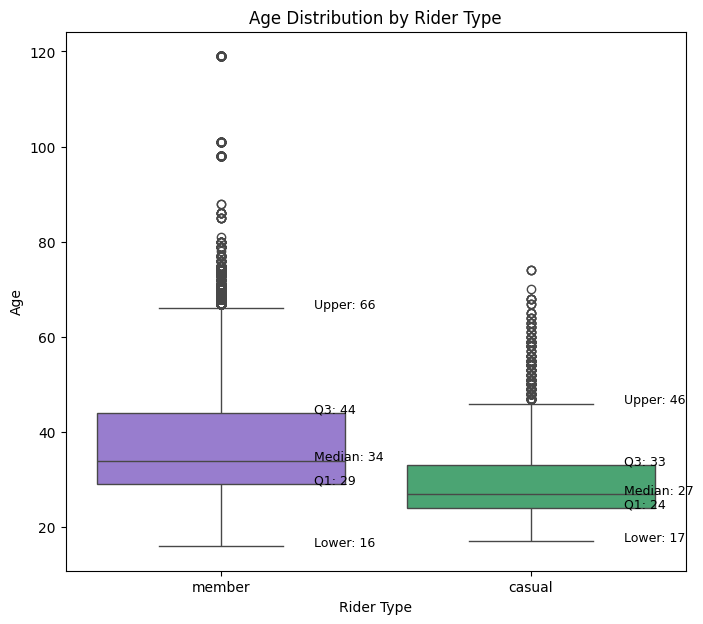

In [71]:
# Boxplot of age distribution by rider type

plt.figure(figsize=(8, 7))
sns.boxplot(x='member_casual', y='age', data=df2019_demographics,
            palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'})

# Annotate member stats
plt.text(0 + 0.3, member_upper_whisker, f'Upper: {member_upper_whisker}', fontsize=9)
plt.text(0 + 0.3, member_q3, f'Q3: {member_q3}', fontsize=9)
plt.text(0 + 0.3, member_median, f'Median: {member_median}', fontsize=9)
plt.text(0 + 0.3, member_q1, f'Q1: {member_q1}', fontsize=9)
plt.text(0 + 0.3, member_lower_whisker, f'Lower: {member_lower_whisker}', fontsize=9)

# Annotate casual stats
plt.text(1 + 0.3, casual_upper_whisker, f'Upper: {casual_upper_whisker}', fontsize=9)
plt.text(1 + 0.3, casual_q3, f'Q3: {casual_q3}', fontsize=9)
plt.text(1 + 0.3, casual_median, f'Median: {casual_median}', fontsize=9)
plt.text(1 + 0.3, casual_q1, f'Q1: {casual_q1}', fontsize=9)
plt.text(1 + 0.3, casual_lower_whisker, f'Lower: {casual_lower_whisker}', fontsize=9)

plt.title('Age Distribution by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Age')
plt.show()

#### Inference:

**Outliers:**

- Both groups have outliers. Clearly, a person above 110 riding a bicycle is an outlier.
- These could be data entry errors and need to be removed

**Median Age:**

- Members median is around 34 years
- Casuals median is around 27 years
- Casuals are noticeably younger than members

**Spread:**

- Members IQR box spans from 29-44 — wider and more diverse
- Casuals IQR box spans roughly 24-33 — narrower and younger

**Whiskers:**

- Members whiskers range from 16-66
- Casuals whiskers range from roughly 17 to 46
- Further confirms casual riders are younger than member riders
  
**Business Insight:**

- Casuals are a younger demographic — Campaigns should look at digital channels and social media for increased conversion to members
- Members represent a broader, more established age range
- Age difference between groups is a key differentiator for marketing strategy

##### Outlier treatment

In [72]:
# Calculate IQR for age
Q1 = df2019_demographics['age'].quantile(0.25)
Q3 = df2019_demographics['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = int(Q1 - 1.5 * IQR)
upper_bound = int(Q3 + 1.5 * IQR)

print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: 6
Upper Bound: 66


**Note**

- A lower bound of 6 does not make sense. Hence, only the upper bound value will used for capping.

In [73]:
# Cap age outliers 
df2019_demographics['age'] = df2019_demographics['age'].clip(upper=upper_bound)

In [74]:
df2019_demographics['age'].describe()

count     345357.0
mean     37.254913
std      11.049661
min           16.0
25%           29.0
50%           34.0
75%           44.0
max           66.0
Name: age, dtype: Float64

- After outlier treatment, age is bounded between 16 (youngest actual rider) and 66 (capped upper bound)

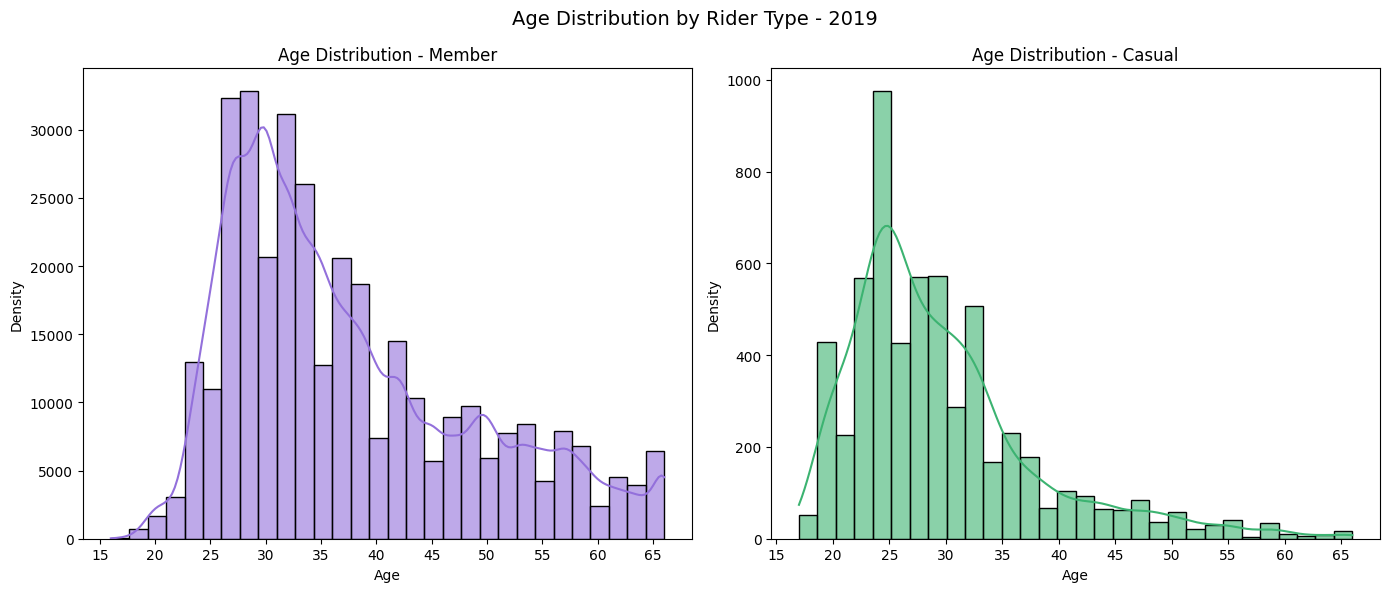

In [75]:
# Age distribution of riders after treating outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, group, color in zip(axes, ['member', 'casual'], ['mediumpurple', 'mediumseagreen']):
    subset = df2019_demographics[df2019_demographics['member_casual'] == group]
    sns.histplot(data=subset, x='age', bins=30, kde=True, 
                 ax=ax, color=color, alpha=0.6)
    ax.set_title(f'Age Distribution - {group.capitalize()}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Density')
    ax.set_xticks(range(15, 70, 5))

plt.suptitle('Age Distribution by Rider Type - 2019', fontsize=14)
plt.tight_layout()
plt.show()

**Age Distribution by Rider Type - 2019 (After Outlier Treatment)**

- Casual riders peak at 24-25 years while members peak between 25-35 years. Casuals are a younger demographic
- Members have a wider, more spread out distribution spanning 20-65, a more diverse range
- Casual riders drop off steeply after 40
- The 20-35 age band is the prime target for casual-to-member conversion campaigns

  
**Business insight:**
- Target conversion campaigns digitally for 20-35 year olds using social media and app-based promotions

### 3.2 Gender Distribution Analysis of 2019 data

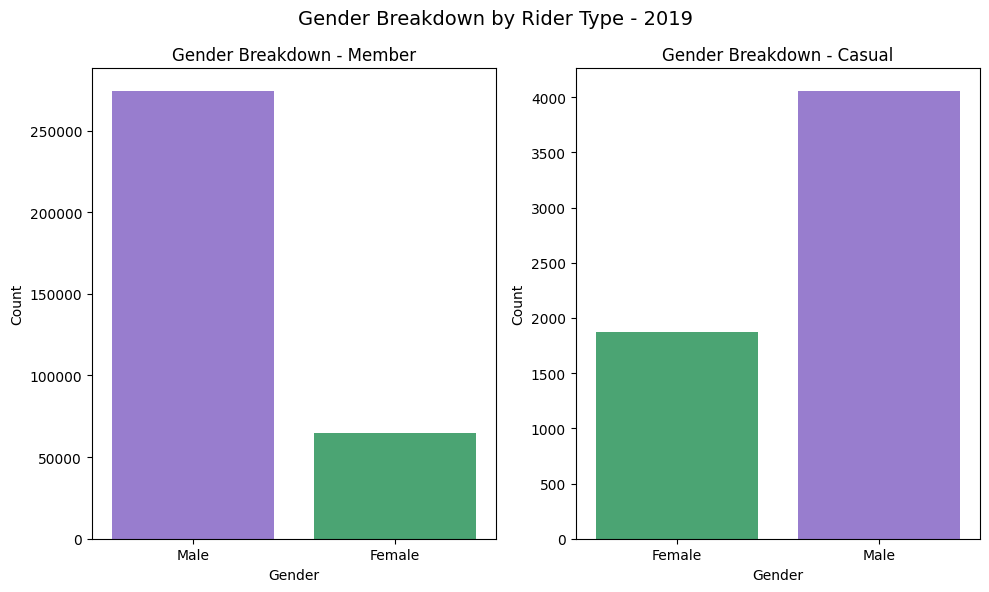

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

for ax, group in zip(axes, ['member', 'casual']):
    subset = df2019_demographics[df2019_demographics['member_casual'] == group]
    sns.countplot(data=subset, x='gender', 
                  palette={'Male': 'mediumpurple', 'Female': 'mediumseagreen'},
                  ax=ax)
    ax.set_title(f'Gender Breakdown - {group.capitalize()}')
    ax.set_xlabel('Gender')
    ax.set_ylabel('Count')

plt.suptitle('Gender Breakdown by Rider Type - 2019', fontsize=14)
plt.tight_layout()
plt.show()

**Gender Breakdown by Rider Type - 2019**

- Both groups are male dominated

**Business insight**
- There is a clear opportunity to target female riders in both categories.
- Marketing campaigns specifically designed for female riders could help close the gender gap and grow overall ridership.

## 3.3 Ride Duration

In [77]:
# Member ride duration stats
member_duration = df[df['member_casual'] == 'member']['ride_duration_min']

member_dur_q1 = round(member_duration.quantile(0.25), 1)
member_dur_median = round(member_duration.median(), 1)
member_dur_q3 = round(member_duration.quantile(0.75), 1)
member_dur_iqr = member_dur_q3 - member_dur_q1
member_dur_upper_whisker = round(min(member_duration.max(), member_dur_q3 + 1.5 * member_dur_iqr), 1)
member_dur_lower_whisker = round(max(member_duration.min(), member_dur_q1 - 1.5 * member_dur_iqr), 1)

# Casual ride duration stats
casual_duration = df[df['member_casual'] == 'casual']['ride_duration_min']

casual_dur_q1 = round(casual_duration.quantile(0.25), 1)
casual_dur_median = round(casual_duration.median(), 1)
casual_dur_q3 = round(casual_duration.quantile(0.75), 1)
casual_dur_iqr = casual_dur_q3 - casual_dur_q1
casual_dur_upper_whisker = round(min(casual_duration.max(), casual_dur_q3 + 1.5 * casual_dur_iqr), 1)
casual_dur_lower_whisker = round(max(casual_duration.min(), casual_dur_q1 - 1.5 * casual_dur_iqr), 1)

# Print all values
print(f"MEMBER - Lower: {member_dur_lower_whisker}, Q1: {member_dur_q1}, Median: {member_dur_median}, Q3: {member_dur_q3}, Upper: {member_dur_upper_whisker}")
print(f"CASUAL - Lower: {casual_dur_lower_whisker}, Q1: {casual_dur_q1}, Median: {casual_dur_median}, Q3: {casual_dur_q3}, Upper: {casual_dur_upper_whisker}")

MEMBER - Lower: 1.0, Q1: 5.3, Median: 8.5, Q3: 13.8, Upper: 26.6
CASUAL - Lower: 1.0, Q1: 13.1, Median: 23.3, Q3: 28.8, Upper: 31.6


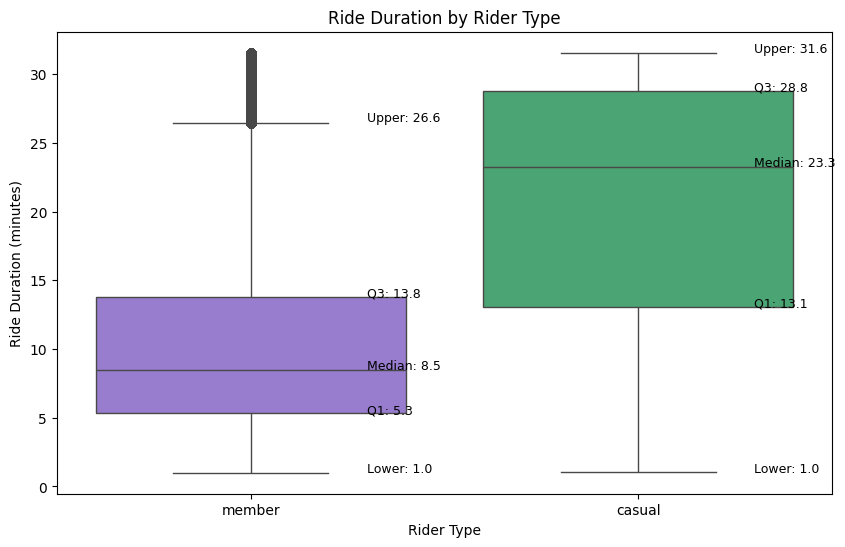

In [78]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='member_casual', y='ride_duration_min', data=df,
            palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'})

# Annotate member stats
plt.text(0 + 0.3, member_dur_upper_whisker, f'Upper: {member_dur_upper_whisker}', fontsize=9)
plt.text(0 + 0.3, member_dur_q3, f'Q3: {member_dur_q3}', fontsize=9)
plt.text(0 + 0.3, member_dur_median, f'Median: {member_dur_median}', fontsize=9)
plt.text(0 + 0.3, member_dur_q1, f'Q1: {member_dur_q1}', fontsize=9)
plt.text(0 + 0.3, member_dur_lower_whisker, f'Lower: {member_dur_lower_whisker}', fontsize=9)

# Annotate casual stats
plt.text(1 + 0.3, casual_dur_upper_whisker, f'Upper: {casual_dur_upper_whisker}', fontsize=9)
plt.text(1 + 0.3, casual_dur_q3, f'Q3: {casual_dur_q3}', fontsize=9)
plt.text(1 + 0.3, casual_dur_median, f'Median: {casual_dur_median}', fontsize=9)
plt.text(1 + 0.3, casual_dur_q1, f'Q1: {casual_dur_q1}', fontsize=9)
plt.text(1 + 0.3, casual_dur_lower_whisker, f'Lower: {casual_dur_lower_whisker}', fontsize=9)

plt.title('Ride Duration by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Ride Duration (minutes)')
plt.show()

**Ride Duration by Rider Type**

- Casual riders have a median ride duration of **~23 minutes** whereas member ride duration is **~8 minutes**
- Members have a shorter ride duration (5-13 mins) suggesting short, purposeful, routine trips
- Casuals show a longer ride duration (13-28 mins) suggesting more unplanned and leisurely rides
- Members have occasional long rides shown as outlier dots above 26 mins (shown as outliers)
- Casual upper whisker reaches 32 mins. Longer rides are expected for this group

**Business insight:** 
- Members are likely commuters using the service for short, planned trips. Casuals are likely leisure or tourist riders taking longer, exploratory rides
- Pricing strategy should highlight the cost savings of membership for frequent short-trip commuters to encourage casual-to-member conversion

## 3.4 Rides by Hour of Day

In [79]:
# Calculate ride counts by hour and rider type
hourly_rides = df.groupby(['hour', 'member_casual']).size().reset_index(name='ride_count')
hourly_rides.head()

,hour,member_casual,ride_count
0,0,casual,465
1,0,member,2938
2,1,casual,331
3,1,member,1728
4,2,casual,248


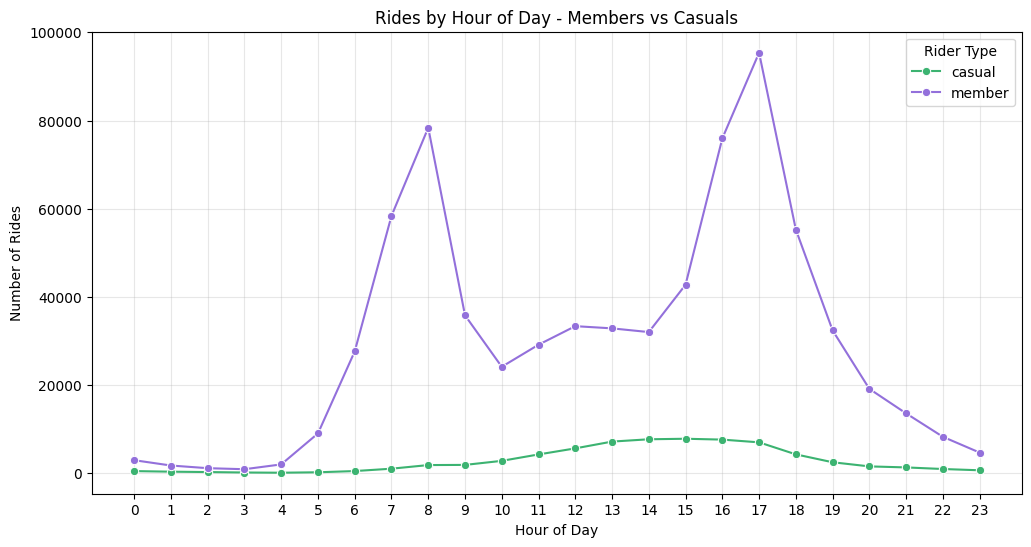

In [80]:
# Plot number of rides by hour of day for member/ casual riders
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_rides, x='hour', y='ride_count', hue='member_casual',
             palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'}, marker='o')
plt.title('Rides by Hour of Day - Members vs Casuals')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24, 1))
plt.legend(title='Rider Type')
plt.grid(True, alpha=0.3)
plt.show()

**Inference**

- Member rides peak at 8am (~75,000 rides) and 5pm (~95,000 rides). This suggests the classic morning and evening commute pattern
- Casuals show a gradual, flat curve, slowly rising from morning, 10am to 6pm, then declining suggesting a typical leisure riding pattern
- Members drop sharply between 8am to 4pm. This could be because they ride to work/ school and back and are busy otherwise.
- Members have a small late night presence (post 10pm). This could be social trips after work/ school.

**Business insight:**
- Members are clearly commuters. Their timings are clearly connected to their work/ school schedules.
- Target casual conversion campaigns during evening peak hours, 1 to 5pm.

## 3.5 Rides by Day of Week

In [81]:
# Calculate ride counts by day of week and rider type
daily_rides = df.groupby(['day_of_week', 'member_casual']).size().reset_index(name='ride_count')
daily_rides.head()

,day_of_week,member_casual,ride_count
0,Friday,casual,7996
1,Friday,member,114624
2,Monday,casual,5580
3,Monday,member,109873
4,Saturday,casual,13456


In [82]:
# Order days correctly as in a week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_rides['day_of_week'] = pd.Categorical(daily_rides['day_of_week'], categories=day_order, ordered=True)
daily_rides = daily_rides.sort_values('day_of_week')
daily_rides.head()

,day_of_week,member_casual,ride_count
2,Monday,casual,5580
3,Monday,member,109873
10,Tuesday,casual,7289
11,Tuesday,member,127391
12,Wednesday,casual,7658


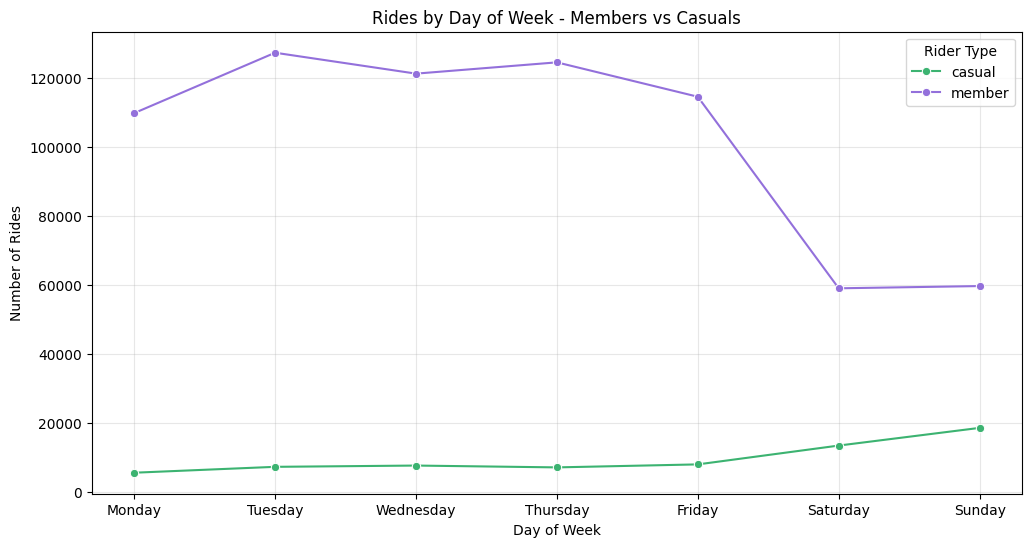

In [83]:
# Plot rides by day of the week for member/ casual riders
plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_rides, x='day_of_week', y='ride_count', hue='member_casual',
             palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'}, marker='o')
plt.title('Rides by Day of Week - Members vs Casuals')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.legend(title='Rider Type')
plt.grid(True, alpha=0.3)
plt.show()

**Inference**

- Members peak on weekdays and drop sharply on weekends, which is a clear commuter pattern
- Casuals show the opposite trend, low on weekdays and rising on weekends, which is a clear leisure pattern

**Business insight:**
- Run conversion campaigns on weekends. That's when casuals are most active and most reachable
- Highlight weekday commute benefits of membership as casuals don't currently see the service as a commute tool

## 3.6 Rides by Month

In [84]:
# Calculate ride counts by month and rider type
monthly_rides = df.groupby(['month', 'member_casual']).size().reset_index(name='ride_count')

# Order months correctly
month_order = ['January', 'February', 'March']
monthly_rides['month'] = pd.Categorical(monthly_rides['month'], categories=month_order, ordered=True)
monthly_rides = monthly_rides.sort_values('month')
monthly_rides.head()

,month,member_casual,ride_count
2,January,casual,12344
3,January,member,233562
0,February,casual,14907
1,February,member,218960
4,March,casual,40441


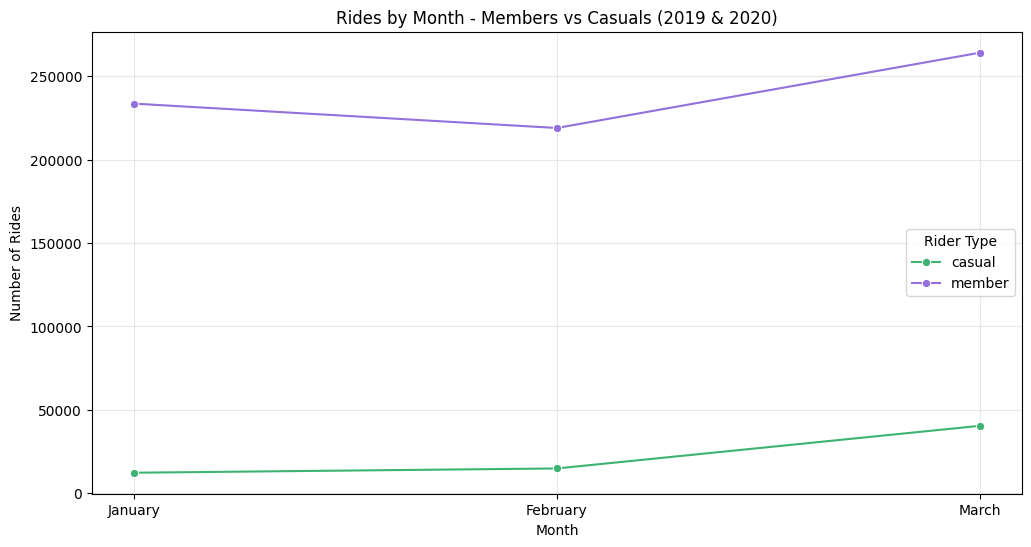

In [85]:
# Plot rider by month for members & casual riders
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_rides, x='month', y='ride_count', hue='member_casual',
             palette={'member': 'mediumpurple', 'casual': 'mediumseagreen'}, marker='o')
plt.title('Rides by Month - Members vs Casuals (2019 & 2020)')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.legend(title='Rider Type')
plt.grid(True, alpha=0.3)
plt.show()

**Inference**

- January shows low ridership for casual riders. This could be because the weather is harsh and outdoor activities are not preferred by many.
- Member ridership is not too low, also not very high. This could be because holiday season has ended and offices/ schools are back to full swing.
- February shows a slight dip for members. This could be because February being the shortest month and or harsh winter weather.
- Both members and casuals show increasing ridership from February to March. This could be because winter is coming to an end and weather is getting warmer.
- March shows highest ridership in both members & casual riders clearly as March is warmer than the previous two months.

**Business insight:** 
- March is a good time to launch conversion campaigns as casual riders are more engaged. This can result in more conversion.
- This is also a good period to launch offers/discounts for spring/ summer season which is a great time to be outdoors.  

## 3.7 Top 10 start stations

In [86]:
# Get top 10 start stations for each rider type
top_stations_member = (df[df['member_casual'] == 'member']
                       .groupby('start_station_name')
                       .size()
                       .reset_index(name='ride_count')
                       .sort_values('ride_count', ascending=False)
                       .head(10))

top_stations_casual = (df[df['member_casual'] == 'casual']
                       .groupby('start_station_name')
                       .size()
                       .reset_index(name='ride_count')
                       .sort_values('ride_count', ascending=False)
                       .head(10))

In [87]:
top_stations_member

,start_station_name,ride_count
86,Canal St & Adams St,13754
156,Clinton St & Washington Blvd,13392
151,Clinton St & Madison St,12838
318,Kingsbury St & Kinzie St,8687
158,Columbus Dr & Randolph St,8467
89,Canal St & Madison St,7861
249,Franklin St & Monroe St,6973
408,Michigan Ave & Washington St,6673
348,Larrabee St & Kingsbury St,6443
150,Clinton St & Lake St,6420


In [88]:
top_stations_casual

,start_station_name,ride_count
546,Streeter Dr & Grand Ave,2741
329,Lake Shore Dr & Monroe St,2731
486,Shedd Aquarium,1829
404,Millennium Park,1404
398,Michigan Ave & Oak St,1015
400,Michigan Ave & Washington St,838
209,Dusable Harbor,832
7,Adler Planetarium,825
548,Theater on the Lake,793
330,Lake Shore Dr & North Blvd,603


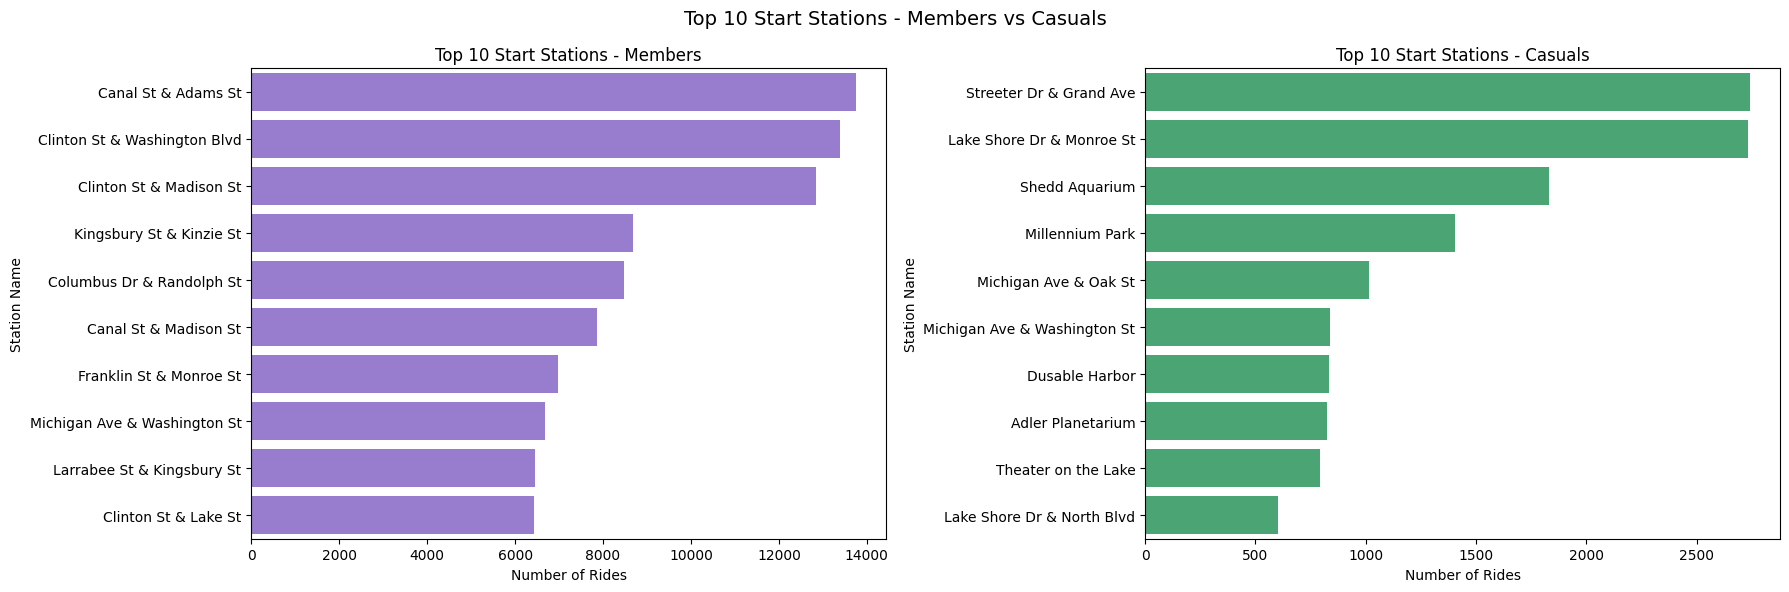

In [89]:
# Plot top 10 start stations for members & casual riders side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Member chart
sns.barplot(data=top_stations_member, x='ride_count', y='start_station_name',
            color='mediumpurple', ax=axes[0])
axes[0].set_title('Top 10 Start Stations - Members')
axes[0].set_xlabel('Number of Rides')
axes[0].set_ylabel('Station Name')

# Casual chart
sns.barplot(data=top_stations_casual, x='ride_count', y='start_station_name',
            color='mediumseagreen', ax=axes[1])
axes[1].set_title('Top 10 Start Stations - Casuals')
axes[1].set_xlabel('Number of Rides')
axes[1].set_ylabel('Station Name')

plt.suptitle('Top 10 Start Stations - Members vs Casuals', fontsize=14)
plt.tight_layout()
plt.show()

**Inference**

- Member top stations are all street intersections (Canal & Adams, Clinton & Washington, 
  Clinton & Madison) — classic office, transit and residential hubs in downtown Chicago, 
  confirming members are commuters
- Canal St & Adams St is the #1 member station with ~14,000 rides — located near 
  major transit hubs and office buildings in the Chicago Loop
- Member ride counts are relatively consistent across the top 10 (6,000–14,000), 
  suggesting commuters are spread across multiple downtown hubs rather than 
  concentrated at one spot
- Casual top stations are almost entirely tourist and leisure destinations — 
  Streeter Dr & Grand Ave (Navy Pier), Shedd Aquarium, Millennium Park, 
  Adler Planetarium, Theater on the Lake
- Streeter Dr & Grand Ave and Lake Shore Dr & Monroe St tie at the top for casuals 
  (~2,700 rides each) — both scenic lakefront locations
- Casual ride counts drop off sharply after the top 4, heavily concentrated 
  around the lakefront and museum campus
- Michigan Ave & Washington St appears in both lists — a crossover point where 
  commuter and tourist activity overlap

**Business insight:**
- Place membership conversion ads at casual hotspot stations — 
  Navy Pier, Shedd Aquarium, Millennium Park — where footfall is highest
- The stark contrast between member and casual station profiles confirms 
  these are two completely different rider personas requiring different 
  marketing strategies

## 3.8 Year-over-Year Comparison (2019 vs 2020)

Q1 2020 covers January, February, and March, the period when COVID-19 lockdowns began in Chicago (mid-March 2020). This section compares rider behaviour across both years to identify any potential impact of the pandemic.

In [90]:
# Total ride volume comparison
total_rides = df.groupby('year').size().reset_index(name='total_rides')
total_rides

,year,total_rides
0,2019,365069
1,2020,419216


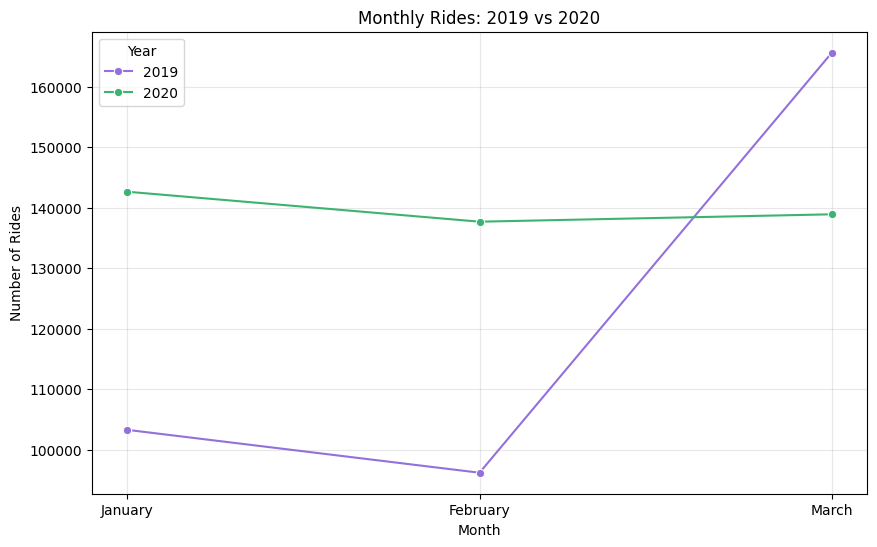

In [91]:
# Monthly rides by year
monthly_yoy = df.groupby(['year', 'month']).size().reset_index(name='ride_count')

month_order = ['January', 'February', 'March']
monthly_yoy['month'] = pd.Categorical(monthly_yoy['month'], categories=month_order, ordered=True)
monthly_yoy = monthly_yoy.sort_values(['year', 'month'])

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_yoy, x='month', y='ride_count', hue='year',
             palette={2019: 'mediumpurple', 2020: 'mediumseagreen'}, marker='o')
plt.title('Monthly Rides: 2019 vs 2020')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.show()

**Inference**

- January and February ridership tracks for 2020 are much higher than that of 2019
- March 2020 shows a sharp drop compared to March 2019. This aligns with COVID-19 lockdowns hitting Chicago in mid-March 2020

# Summary

**Inference**

- Casual riders take longer rides (~23 min) vs members (~8 min) suggesting leisure vs commute usage
- Members show a clear commute pattern, peaking at 8am and 5pm on weekdays
- Casuals rides are seen mostly on weekends and midday confirming recreational usage
- Both groups increase ridership in March suggesting the effect of warmer weather on bike rides
- Casual top stations are tourist hotspots such as Millennium Park, Shedd Aquarium, Navy Pier area
- Member top stations are office and transit hubs: downtown street intersections
- Casuals are younger (mostly 24-25 age group) vs members (mostly 25-35 age group)
- Both groups are male dominated
- Q1 2020 ridership dropped sharply in March compared to 2019, consistent with COVID-19 lockdowns beginning mid-March 2020

**Business Recommendations**

- Launch weekend conversion campaigns at casual hotspot stations with membership pricing incentives
- Highlight cost savings of membership for riders who use the service more than 3x per week
- Target 25-35 age group digitally via social media for casual-to-member conversion
- Design female-focused campaigns to grow the female rider segment
- Increase marketing efforts in March when casual ridership is growing fastest to tap in the spring/summer warm weather effect

## Conclusion

This analysis confirms that members and casuals represent two distinct rider personas — commuters and leisure riders respectively. Converting casual riders requires targeted weekend campaigns, digital outreach to the 20-35 age group, and clear communication of membership cost benefits. The year-over-year comparison also reveals a sharp ridership drop in March 2020, aligning with the onset of COVID-19 lockdowns in Chicago — a real-world event clearly visible in the data.